# Memory Performance Analysis

This notebook analyses the resident-memory usage of Node.js, Bun and Deno under two controlled workloads: Idle and Allocated.

Memory usage was measured externally using Resident Set Size (RSS). The primary performance metric is the median post-READY RSS in MiB, calculated during the steady-state sampling period after the benchmark workload emitted the expected `READY` signal.

The Idle workload represents the runtime's baseline resident-memory footprint, while the Allocated workload retains a controlled 100 MiB `Uint8Array`.

Lower RSS indicates lower resident-memory consumption.

The analysis includes:

1. Dataset import and verification
2. Descriptive statistics
3. Visualisation
4. Assumption diagnostics
5. Repeated-measures omnibus testing
6. Pairwise post-hoc comparisons
7. Holm correction for multiple comparisons
8. Effect-size estimation and 95% confidence intervals

In [1]:
library(tidyverse)
library(rstatix)
library(effectsize)

current_dir <- normalizePath(
  getwd(),
  winslash = "/"
)

project_root <- if (
  basename(current_dir) == "notebooks"
) {
  dirname(current_dir)
} else {
  current_dir
}

project_root

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rstatix' was built under R version 4.6.1"

Attaching package: 'rstatix'


The following object is masked from 'package:stats':

    filter


Warning message:
"package 'effectsize' was built under R version 4.6.1"

Attaching package: 'effectsize'


The following objects are masked from 'package:rstatix':

    cohens_d, eta_squared, omega_squared




[1] "D:/FOLO_PROJECTS/MASTERS/javascript-runtime-performance-study"

In [2]:
memory_final <- read_csv(
  file.path(
    project_root,
    "data",
    "processed",
    "memory",
    "memory_final.csv"
  ),
  show_col_types = FALSE
)

glimpse(memory_final)

Rows: 120
Columns: 31
$ run_id                      <chr> "memory_s01_r01_bun_allocated", "memory_s0…
$ session_id                  <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ sequence                    <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,…
$ repetition                  <dbl> 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, …
$ runtime                     <chr> "bun", "node", "deno", "bun", "deno", "nod…
$ workload                    <chr> "allocated", "allocated", "idle", "idle", …
$ shuffle_seed                <dbl> 20260811, 20260811, 20260811, 20260811, 20…
$ started_at                  <dttm> 2026-08-10 19:25:44, 2026-08-10 19:25:49,…
$ ready_at                    <dttm> 2026-08-10 19:25:44, 2026-08-10 19:25:49,…
$ finished_at                 <dttm> 2026-08-10 19:25:46, 2026-08-10 19:25:51,…
$ status                      <chr> "success", "success", "success", "success"…
$ allocation_bytes            <dbl> 104857600, 104857600, 0, 0, 104857600, 0, …
$ sample_interval_

In [3]:
dim(memory_final)
names(memory_final)
table(memory_final$runtime)
table(memory_final$workload)

table(
  memory_final$runtime,
  memory_final$workload
)

[1] 120  31

[1] "run_id"                      "session_id"                 
 [3] "sequence"                    "repetition"                 
 [5] "runtime"                     "workload"                   
 [7] "shuffle_seed"                "started_at"                 
 [9] "ready_at"                    "finished_at"                
[11] "status"                      "allocation_bytes"           
[13] "sample_interval_ms"          "post_ready_window_ms"       
[15] "pre_ready_samples"           "post_ready_samples"         
[17] "rss_at_ready_bytes"          "rss_at_ready_mib"           
[19] "median_post_ready_rss_bytes" "median_post_ready_rss_mib"  
[21] "mean_post_ready_rss_bytes"   "mean_post_ready_rss_mib"    
[23] "peak_post_ready_rss_bytes"   "peak_post_ready_rss_mib"    
[25] "peak_observed_rss_bytes"     "peak_observed_rss_mib"      
[27] "ready_payload"               "sample_file"                
[29] "stdout_log"                  "stderr_log"                 
[31] "error_message"


 bun deno node 
  40   40   40 


allocated      idle 
       60        60 

      
       allocated idle
  bun         20   20
  deno        20   20
  node        20   20

In [4]:
memory_checks <- tibble(
  total_observations = nrow(memory_final),

  missing_primary_rss =
    sum(is.na(memory_final$median_post_ready_rss_mib)),

  non_positive_primary_rss =
    sum(memory_final$median_post_ready_rss_mib <= 0),

  failed_observations =
    sum(memory_final$status != "success"),

  unique_repetitions =
    n_distinct(memory_final$repetition),

  incorrect_idle_allocation =
    sum(
      memory_final$workload == "Idle" &
      memory_final$allocation_bytes != 0
    ),

  incorrect_allocated_size =
    sum(
      memory_final$workload == "Allocated" &
      memory_final$allocation_bytes != 104857600
    )
)

memory_checks

total_observations,missing_primary_rss,non_positive_primary_rss,failed_observations,unique_repetitions,incorrect_idle_allocation,incorrect_allocated_size
<int>,<int>,<int>,<int>,<int>,<int>,<int>
120,0,0,0,20,0,0


In [5]:
memory_final |>
  count(repetition) |>
  count(n)

Storing counts in `nn`, as `n` already present in input
ℹ Use `name = "new_name"` to pick a new name.


n,nn
<int>,<int>
6,20


In [8]:
memory_final <- memory_final |>
  mutate(
    runtime = factor(
      runtime,
      levels = c("node", "bun", "deno"),
      labels = c("Node.js", "Bun", "Deno")
    ),
    workload = factor(
      workload,
      levels = c("idle", "allocated"),
      labels = c("Idle", "Allocated")
    )
  )

table(memory_final$runtime, memory_final$workload)

         
          Idle Allocated
  Node.js   20        20
  Bun       20        20
  Deno      20        20

In [9]:
# primary descriptive statistic
memory_median_summary <- memory_final |>
  group_by(
    workload,
    runtime
  ) |>
  summarise(
    n = n(),

    mean_mib =
      mean(median_post_ready_rss_mib),

    median_mib =
      median(median_post_ready_rss_mib),

    sd_mib =
      sd(median_post_ready_rss_mib),

    se_mib =
      sd_mib / sqrt(n),

    ci_margin =
      qt(0.975, df = n - 1) * se_mib,

    ci_lower =
      mean_mib - ci_margin,

    ci_upper =
      mean_mib + ci_margin,

    iqr_mib =
      IQR(median_post_ready_rss_mib),

    min_mib =
      min(median_post_ready_rss_mib),

    max_mib =
      max(median_post_ready_rss_mib),

    .groups = "drop"
  )

memory_median_summary

workload,runtime,n,mean_mib,median_mib,sd_mib,se_mib,ci_margin,ci_lower,ci_upper,iqr_mib,min_mib,max_mib
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Idle,Node.js,20,36.70469,36.69531,0.04277956,0.009565801,0.020021452,36.68467,36.72471,0.05078125,36.61328,36.78125
Idle,Bun,20,55.91328,55.91406,0.01486646,0.003324241,0.006957716,55.90632,55.92024,0.02441406,55.88672,55.93750
Idle,Deno,20,42.39531,42.42773,0.11799747,0.026385038,0.055224518,42.34009,42.45054,0.10839844,42.13281,42.57812
Allocated,Node.js,20,137.29707,137.28906,0.02795300,0.006250482,0.013082409,137.28399,137.31015,0.03710938,137.25781,137.36719
Allocated,Bun,20,155.99160,156.00195,0.05410099,0.012097349,0.025320041,155.96628,156.01692,0.01562500,155.76953,156.04688
Allocated,Deno,20,142.90625,142.93945,0.11904369,0.026618978,0.055714161,142.85054,142.96196,0.10156250,142.63281,143.09375


In [10]:
# peak RSS summary

memory_peak_summary <- memory_final |>
  group_by(
    workload,
    runtime
  ) |>
  summarise(
    mean_peak_mib =
      mean(peak_post_ready_rss_mib),

    median_peak_mib =
      median(peak_post_ready_rss_mib),

    sd_peak_mib =
      sd(peak_post_ready_rss_mib),

    min_peak_mib =
      min(peak_post_ready_rss_mib),

    max_peak_mib =
      max(peak_post_ready_rss_mib),

    .groups = "drop"
  )

memory_peak_summary

workload,runtime,mean_peak_mib,median_peak_mib,sd_peak_mib,min_peak_mib,max_peak_mib
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Idle,Node.js,36.70723,36.69531,0.03834612,36.64844,36.78125
Idle,Bun,55.94375,55.94336,0.01452767,55.91797,55.96875
Idle,Deno,42.39531,42.42773,0.11799747,42.13281,42.57812
Allocated,Node.js,137.29707,137.28906,0.02795300,137.25781,137.36719
Allocated,Bun,156.01523,156.01953,0.03383861,155.88672,156.06250
Allocated,Deno,142.90625,142.93945,0.11904369,142.63281,143.09375


### Memory Descriptive Results

Median post-READY RSS was used as the primary measure of steady-state resident-memory consumption, with lower values indicating lower memory usage.

Under the **Idle** workload, Node.js recorded the lowest mean RSS (36.70 MiB), followed by Deno (42.40 MiB) and Bun (55.91 MiB).

The same ordering was observed under the **Allocated** workload. Node.js again recorded the lowest mean RSS (137.30 MiB), followed by Deno (142.91 MiB) and Bun (155.99 MiB).

The transition from Idle to Allocated increased mean RSS by approximately 100 MiB for all three runtimes, consistent with the controlled 100 MiB allocation used by the benchmark.

Variation within each runtime–workload group was very small, indicating highly stable steady-state memory measurements across the 20 repetitions. Peak post-READY RSS was also very close to median post-READY RSS across the groups.

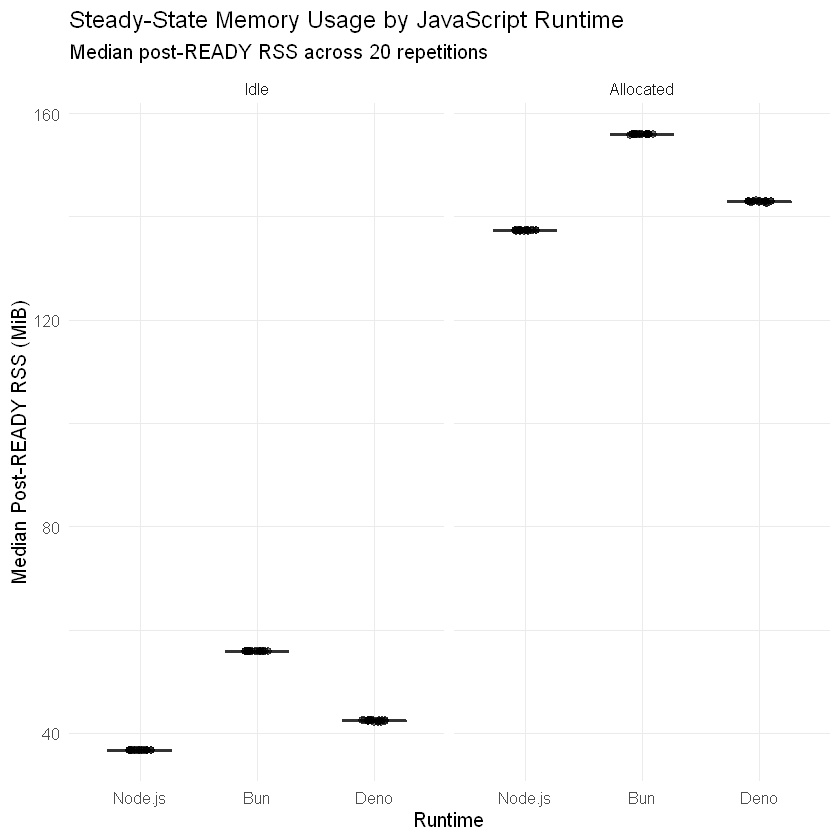

In [11]:
memory_plot <- ggplot(
  memory_final,
  aes(
    x = runtime,
    y = median_post_ready_rss_mib
  )
) +
  geom_boxplot(
    width = 0.55,
    outlier.shape = NA
  ) +
  geom_jitter(
    width = 0.10,
    alpha = 0.55,
    size = 1.8
  ) +
  facet_wrap(~ workload) +
  labs(
    title = "Steady-State Memory Usage by JavaScript Runtime",
    subtitle = "Median post-READY RSS across 20 repetitions",
    x = "Runtime",
    y = "Median Post-READY RSS (MiB)"
  ) +
  theme_minimal(base_size = 12)

memory_plot

In [12]:
# match wide table

memory_wide <- memory_final |>
  select(
    repetition,
    workload,
    runtime,
    median_post_ready_rss_mib
  ) |>
  pivot_wider(
    names_from = runtime,
    values_from = median_post_ready_rss_mib
  )

dim(memory_wide)
colSums(is.na(memory_wide))

[1] 40  5

repetition   workload        Bun    Node.js       Deno 
         0          0          0          0          0

In [13]:
memory_differences <- memory_wide |>
  mutate(
    `Node.js - Bun` = `Node.js` - Bun,
    `Node.js - Deno` = `Node.js` - Deno,
    `Bun - Deno` = Bun - Deno
  ) |>
  select(
    repetition,
    workload,
    `Node.js - Bun`,
    `Node.js - Deno`,
    `Bun - Deno`
  ) |>
  pivot_longer(
    cols = c(
      `Node.js - Bun`,
      `Node.js - Deno`,
      `Bun - Deno`
    ),
    names_to = "comparison",
    values_to = "difference"
  )

In [14]:
# shapiro wilk

memory_shapiro <- memory_differences |>
  group_by(
    workload,
    comparison
  ) |>
  summarise(
    W = unname(
      shapiro.test(difference)$statistic
    ),
    p_value =
      shapiro.test(difference)$p.value,
    .groups = "drop"
  )

memory_shapiro

workload,comparison,W,p_value
<fct>,<chr>,<dbl>,<dbl>
Idle,Bun - Deno,0.9015120,0.0440241457
Idle,Node.js - Bun,0.9386308,0.2258804384
Idle,Node.js - Deno,0.9343966,0.1875548327
Allocated,Bun - Deno,0.9219148,0.1078656242
Allocated,Node.js - Bun,0.7121114,0.0000549782
Allocated,Node.js - Deno,0.9350137,0.1927255199


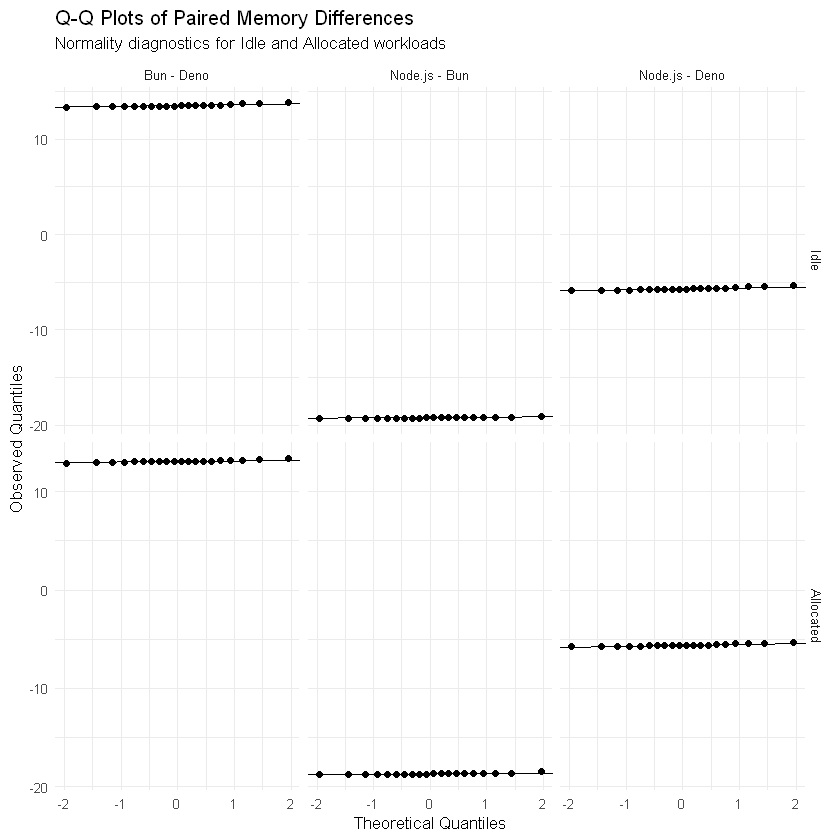

In [15]:
memory_qq <- ggplot(
  memory_differences,
  aes(sample = difference)
) +
  stat_qq(size = 1.7) +
  stat_qq_line() +
  facet_grid(
    workload ~ comparison,
    scales = "free"
  ) +
  labs(
    title = "Q-Q Plots of Paired Memory Differences",
    subtitle = "Normality diagnostics for Idle and Allocated workloads",
    x = "Theoretical Quantiles",
    y = "Observed Quantiles"
  ) +
  theme_minimal(base_size = 10)

memory_qq

### Memory Assumption Assessment and Test Selection

Normality of the paired runtime differences was assessed separately for the Idle and Allocated workloads using Shapiro–Wilk tests and Q–Q plots.

For the **Idle workload**, the Bun–Deno paired differences showed a statistically significant departure from normality (W = .902, p = .044), while the Node.js–Bun (W = .939, p = .226) and Node.js–Deno (W = .934, p = .188) comparisons did not show statistically significant departures. Although the Q–Q plots showed that most observations followed the reference lines reasonably closely, the normality assumption was not consistently satisfied across all three paired contrasts.

For the **Allocated workload**, the Node.js–Bun paired differences showed a strong departure from normality (W = .712, p < .001; exact p = .000055). The Bun–Deno (W = .922, p = .108) and Node.js–Deno (W = .935, p = .193) comparisons did not show statistically significant departures. The Q–Q plots were generally close to the reference lines, but the Shapiro–Wilk result for Node.js–Bun provided clear evidence that normality could not be assumed consistently for the Allocated workload.

Because the normality assumption was not consistently supported within either workload, the non-parametric **Friedman test** was selected for both Idle and Allocated memory comparisons. This test is appropriate for the matched repeated-measures design and does not require normally distributed paired differences.

In [16]:
memory_friedman_idle <- stats::friedman.test(
  median_post_ready_rss_mib ~ runtime | repetition,
  data = memory_final |>
    filter(workload == "Idle")
)

memory_friedman_allocated <- stats::friedman.test(
  median_post_ready_rss_mib ~ runtime | repetition,
  data = memory_final |>
    filter(workload == "Allocated")
)

memory_friedman_idle
memory_friedman_allocated


	Friedman rank sum test

data:  median_post_ready_rss_mib and runtime and repetition
Friedman chi-squared = 40, df = 2, p-value = 2.061e-09



	Friedman rank sum test

data:  median_post_ready_rss_mib and runtime and repetition
Friedman chi-squared = 40, df = 2, p-value = 2.061e-09


In [17]:
memory_friedman_results <- tibble(
  workload = c("Idle", "Allocated"),

  chi_square = c(
    unname(memory_friedman_idle$statistic),
    unname(memory_friedman_allocated$statistic)
  ),

  df = c(
    unname(memory_friedman_idle$parameter),
    unname(memory_friedman_allocated$parameter)
  ),

  p_value = c(
    memory_friedman_idle$p.value,
    memory_friedman_allocated$p.value
  )
) |>
  mutate(
    kendalls_w =
      chi_square / (20 * (3 - 1))
  )

memory_friedman_results

workload,chi_square,df,p_value,kendalls_w
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Idle,40,2,2.061154e-09,1
Allocated,40,2,2.061154e-09,1


### Friedman Test Results for Memory Usage

The Friedman tests identified statistically significant differences in median post-READY RSS between Node.js, Bun and Deno under both memory workloads.

For the **Idle workload**, a statistically significant runtime effect was observed, χ²(2) = 40.00, p < .001, with Kendall's W = 1.00.

The **Allocated workload** produced the same omnibus result, χ²(2) = 40.00, p < .001, with Kendall's W = 1.00.

A Kendall's W of 1.00 indicates complete consistency in the relative ranking of the three runtimes across all 20 matched repetitions. In both workloads, Node.js recorded the lowest RSS, followed by Deno and then Bun.

Because both omnibus Friedman tests were statistically significant, paired post-hoc comparisons were conducted to determine whether each runtime pair differed significantly.

In [18]:
memory_exact_check <- memory_differences |>
  group_by(
    workload,
    comparison
  ) |>
  summarise(
    zero_differences =
      sum(difference == 0),

    duplicated_absolute_differences =
      sum(
        duplicated(abs(difference))
      ),

    .groups = "drop"
  )

memory_exact_check

workload,comparison,zero_differences,duplicated_absolute_differences
<fct>,<chr>,<int>,<int>
Idle,Bun - Deno,0,2
Idle,Node.js - Bun,0,6
Idle,Node.js - Deno,0,1
Allocated,Bun - Deno,0,0
Allocated,Node.js - Bun,0,4
Allocated,Node.js - Deno,0,0


### Post-Hoc Test Selection

The omnibus Friedman tests were statistically significant for both memory workloads, requiring pairwise post-hoc comparisons.

Inspection of the paired differences found no zero differences, but tied absolute differences were present in several runtime comparisons. Because ties prevent straightforward use of the standard exact Wilcoxon signed-rank calculation, a tie-aware exact signed-rank permutation procedure was used for all six memory comparisons.

Holm's correction was subsequently applied across the six pairwise tests within the memory metric family.

In [19]:
exact_signed_rank_test <- function(differences) {

  differences <- differences[differences != 0]

  n <- length(differences)

  if (n == 0) {
    return(
      tibble(
        statistic = 0,
        p_value = 1,
        n_nonzero = 0
      )
    )
  }

  ranks <- rank(
    abs(differences),
    ties.method = "average"
  )

  observed_statistic <-
    sum(ranks[differences > 0])

  total_rank <-
    sum(ranks)

  expected_statistic <-
    total_rank / 2

  observed_distance <-
    abs(
      observed_statistic -
      expected_statistic
    )

  # Enumerate every possible +/- sign allocation
  permutations <- expand.grid(
    rep(
      list(c(-1, 1)),
      n
    )
  )

  permutation_statistics <- apply(
    permutations,
    1,
    function(signs) {
      sum(ranks[signs > 0])
    }
  )

  permutation_distances <-
    abs(
      permutation_statistics -
      expected_statistic
    )

  p_value <-
    mean(
      permutation_distances >=
        observed_distance
    )

  tibble(
    statistic = observed_statistic,
    p_value = p_value,
    n_nonzero = n
  )
}

In [20]:
memory_posthoc <- memory_differences |>
  separate(
    comparison,
    into = c("group1", "group2"),
    sep = " - ",
    remove = FALSE
  ) |>
  group_by(
    workload,
    group1,
    group2
  ) |>
  group_modify(
    ~ {

      result <-
        exact_signed_rank_test(
          .x$difference
        )

      tibble(
        statistic =
          result$statistic,

        p_raw =
          result$p_value,

        n_nonzero =
          result$n_nonzero,

        median_difference =
          median(.x$difference)
      )
    }
  ) |>
  ungroup() |>
  mutate(
    p_holm =
      p.adjust(
        p_raw,
        method = "holm"
      ),

    significant =
      ifelse(
        p_holm < .05,
        "Yes",
        "No"
      )
  )

memory_posthoc

workload,group1,group2,statistic,p_raw,n_nonzero,median_difference,p_holm,significant
<fct>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
Idle,Bun,Deno,210,1.907349e-06,20,13.482422,1.144409e-05,Yes
Idle,Node.js,Bun,0,1.907349e-06,20,-19.220703,1.144409e-05,Yes
Idle,Node.js,Deno,0,1.907349e-06,20,-5.716797,1.144409e-05,Yes
Allocated,Bun,Deno,210,1.907349e-06,20,13.060547,1.144409e-05,Yes
Allocated,Node.js,Bun,0,1.907349e-06,20,-18.707031,1.144409e-05,Yes
Allocated,Node.js,Deno,0,1.907349e-06,20,-5.628906,1.144409e-05,Yes


### Memory Post-Hoc Results

Following the statistically significant Friedman tests, pairwise signed-rank permutation tests were conducted for the three runtime comparisons within each workload. A tie-aware exact procedure was used because tied absolute differences were present in several comparisons. Holm's correction was applied across all six pairwise comparisons in the memory metric family.

For the **Idle workload**, all three runtime pairs differed significantly after correction. Node.js used less resident memory than Bun (median paired difference = -19.22 MiB, Holm-adjusted p < .001) and Deno (-5.72 MiB, Holm-adjusted p < .001). Deno also used less memory than Bun, with the Bun–Deno comparison producing a median paired difference of 13.48 MiB (Holm-adjusted p < .001).

The same pattern occurred under the **Allocated workload**. Node.js used less memory than Bun (median paired difference = -18.71 MiB, Holm-adjusted p < .001) and Deno (-5.63 MiB, Holm-adjusted p < .001). Deno again used less memory than Bun, with a median Bun–Deno difference of 13.06 MiB (Holm-adjusted p < .001).

All 20 matched repetitions within each comparison favoured the same runtime. The post-hoc results therefore support the consistent memory-efficiency ordering **Node.js → Deno → Bun** for both Idle and Allocated workloads.

In [21]:
paired_rank_biserial <- function(differences) {

  differences <- differences[differences != 0]

  if (length(differences) == 0) {
    return(NA_real_)
  }

  ranks <- rank(
    abs(differences),
    ties.method = "average"
  )

  positive_rank <-
    sum(ranks[differences > 0])

  negative_rank <-
    sum(ranks[differences < 0])

  (
    positive_rank - negative_rank
  ) / (
    positive_rank + negative_rank
  )
}

In [22]:
set.seed(7303)

memory_effects <- memory_differences |>
  separate(
    comparison,
    into = c("group1", "group2"),
    sep = " - ",
    remove = FALSE
  ) |>
  group_by(
    workload,
    group1,
    group2
  ) |>
  group_modify(
    ~ {

      differences <- .x$difference
      n <- length(differences)

      observed_effect <-
        paired_rank_biserial(differences)

      bootstrap_results <- replicate(
        5000,
        {
          sampled_differences <- sample(
            differences,
            size = n,
            replace = TRUE
          )

          c(
            effect =
              paired_rank_biserial(
                sampled_differences
              ),

            median_difference =
              median(sampled_differences)
          )
        }
      )

      tibble(
        median_difference =
          median(differences),

        difference_ci_lower =
          quantile(
            bootstrap_results[
              "median_difference",
            ],
            0.025,
            na.rm = TRUE
          ),

        difference_ci_upper =
          quantile(
            bootstrap_results[
              "median_difference",
            ],
            0.975,
            na.rm = TRUE
          ),

        effect_type =
          "Rank-biserial correlation",

        effect_size =
          observed_effect,

        effect_ci_lower =
          quantile(
            bootstrap_results[
              "effect",
            ],
            0.025,
            na.rm = TRUE
          ),

        effect_ci_upper =
          quantile(
            bootstrap_results[
              "effect",
            ],
            0.975,
            na.rm = TRUE
          )
      )
    }
  ) |>
  ungroup()

memory_effects

workload,group1,group2,median_difference,difference_ci_lower,difference_ci_upper,effect_type,effect_size,effect_ci_lower,effect_ci_upper
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Idle,Bun,Deno,13.482422,13.449219,13.531250,Rank-biserial correlation,1,1,1
Idle,Node.js,Bun,-19.220703,-19.232422,-19.201172,Rank-biserial correlation,-1,-1,-1
Idle,Node.js,Deno,-5.716797,-5.761719,-5.650391,Rank-biserial correlation,-1,-1,-1
Allocated,Bun,Deno,13.060547,13.044922,13.099609,Rank-biserial correlation,1,1,1
Allocated,Node.js,Bun,-18.707031,-18.726562,-18.693359,Rank-biserial correlation,-1,-1,-1
Allocated,Node.js,Deno,-5.628906,-5.677734,-5.585938,Rank-biserial correlation,-1,-1,-1


### Memory Effect Sizes

Matched-pairs rank-biserial correlations were calculated to quantify the magnitude and direction of the runtime differences. Paired bootstrap resampling was used to obtain 95% confidence intervals for the median paired differences and effect sizes.

Under the **Idle workload**, Node.js used less memory than Bun by a median of 19.22 MiB (95% CI [19.20, 19.23] MiB in absolute magnitude) and less than Deno by 5.72 MiB (95% CI [5.65, 5.76] MiB). Deno used less memory than Bun by 13.48 MiB (95% CI [13.45, 13.53] MiB).

Under the **Allocated workload**, Node.js used less memory than Bun by 18.71 MiB (95% CI [18.69, 18.73] MiB) and less than Deno by 5.63 MiB (95% CI [5.59, 5.68] MiB). Deno used less memory than Bun by 13.06 MiB (95% CI [13.04, 13.10] MiB).

All six comparisons produced rank-biserial correlations with an absolute value of 1.00. This indicates complete directional separation: the lower-memory runtime in each comparison used less resident memory in every one of the 20 matched repetitions.

Taken together, the descriptive statistics, Friedman tests, post-hoc comparisons and effect sizes consistently produced the memory-efficiency ordering **Node.js → Deno → Bun** for both Idle and Allocated workloads.

In [23]:
memory_final_results <- memory_posthoc |>
  left_join(
    memory_effects |>
      select(
        workload,
        group1,
        group2,
        difference_ci_lower,
        difference_ci_upper,
        effect_type,
        effect_size,
        effect_ci_lower,
        effect_ci_upper
      ),
    by = c(
      "workload",
      "group1",
      "group2"
    )
  ) |>
  select(
    workload,
    group1,
    group2,
    median_difference,
    difference_ci_lower,
    difference_ci_upper,
    p_raw,
    p_holm,
    significant,
    n_nonzero,
    effect_type,
    effect_size,
    effect_ci_lower,
    effect_ci_upper
  )

memory_final_results

workload,group1,group2,median_difference,difference_ci_lower,difference_ci_upper,p_raw,p_holm,significant,n_nonzero,effect_type,effect_size,effect_ci_lower,effect_ci_upper
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>
Idle,Bun,Deno,13.482422,13.449219,13.531250,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,1,1,1
Idle,Node.js,Bun,-19.220703,-19.232422,-19.201172,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,-1,-1,-1
Idle,Node.js,Deno,-5.716797,-5.761719,-5.650391,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,-1,-1,-1
Allocated,Bun,Deno,13.060547,13.044922,13.099609,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,1,1,1
Allocated,Node.js,Bun,-18.707031,-18.726562,-18.693359,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,-1,-1,-1
Allocated,Node.js,Deno,-5.628906,-5.677734,-5.585938,1.907349e-06,1.144409e-05,Yes,20,Rank-biserial correlation,-1,-1,-1


In [24]:
memory_results_directory <- file.path(
  project_root,
  "results",
  "tables",
  "memory"
)

dir.create(
  memory_results_directory,
  recursive = TRUE,
  showWarnings = FALSE
)

In [25]:
write_csv(
  memory_median_summary,
  file.path(
    memory_results_directory,
    "memory_median_rss_descriptive_summary.csv"
  )
)

write_csv(
  memory_peak_summary,
  file.path(
    memory_results_directory,
    "memory_peak_rss_descriptive_summary.csv"
  )
)

write_csv(
  memory_friedman_results,
  file.path(
    memory_results_directory,
    "memory_friedman_results.csv"
  )
)

write_csv(
  memory_final_results,
  file.path(
    memory_results_directory,
    "memory_inferential_results.csv"
  )
)

In [26]:
list.files(memory_results_directory)

[1] "memory_final_audit_summary.csv"           
[2] "memory_friedman_results.csv"              
[3] "memory_inferential_results.csv"           
[4] "memory_median_rss_descriptive_summary.csv"
[5] "memory_peak_rss_descriptive_summary.csv"